In [9]:
import pandas as pd
from experiment_utils import run_one_experiment, run, save_result, MLPClassifier, save_result_v1

In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  1239 non-null   str    
 1   home_team             1239 non-null   str    
 2   away_team             1239 non-null   str    
 3   home_score            1239 non-null   float64
 4   away_score            1239 non-null   float64
 5   tournament            1239 non-null   str    
 6   city                  1239 non-null   str    
 7   country               1239 non-null   str    
 8   neutral               1239 non-null   int64  
 9   year                  1239 non-null   int64  
 10  is_world_cup          1239 non-null   int64  
 11  is_qualifier          1239 non-null   int64  
 12  match_id              1239 non-null   int64  
 13  home_rank_date_used   1239 non-null   str    
 14  home_rank             1239 non-null   float64
 15  home_previous_rank    1239 non-n

In [3]:
## Splitting the data
X = data[['home_elo', 'away_elo']]
y = data['result']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

label_mapping = {
   -1: 0,
    0: 1,
    1: 2
}
y_enc = y.map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, shuffle = False)



scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


In [5]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8051 | val loss = 0.7794 | val acc = 0.6583
Epoch 100/1000 | train loss = 0.7984 | val loss = 0.7785 | val acc = 0.6482
Epoch 150/1000 | train loss = 0.7978 | val loss = 0.7781 | val acc = 0.6332
Epoch 200/1000 | train loss = 0.7756 | val loss = 0.7782 | val acc = 0.6382
Epoch 250/1000 | train loss = 0.7829 | val loss = 0.7814 | val acc = 0.6332
Epoch 300/1000 | train loss = 0.7886 | val loss = 0.7833 | val acc = 0.6382
Epoch 350/1000 | train loss = 0.7834 | val loss = 0.7855 | val acc = 0.6432
Epoch 400/1000 | train loss = 0.7764 | val loss = 0.7892 | val acc = 0.6432
Epoch 450/1000 | train loss = 0.7865 | val loss = 0.7855 | val acc = 0.6382
Epoch 500/1000 | train loss = 0.7837 | val loss = 0.7884 | val acc = 0.6382
Epoch 550/1000 | train loss = 0.7866 | val loss = 0.7900 | val acc = 0.6332
Epoch 600/1000 | train loss = 0.7829 | val loss = 0.7926 | val acc = 0.6231
Epoch 650/1000 | train loss = 0.7688 | val loss = 0.7964 | val acc = 0.6332
Epoch 700/100

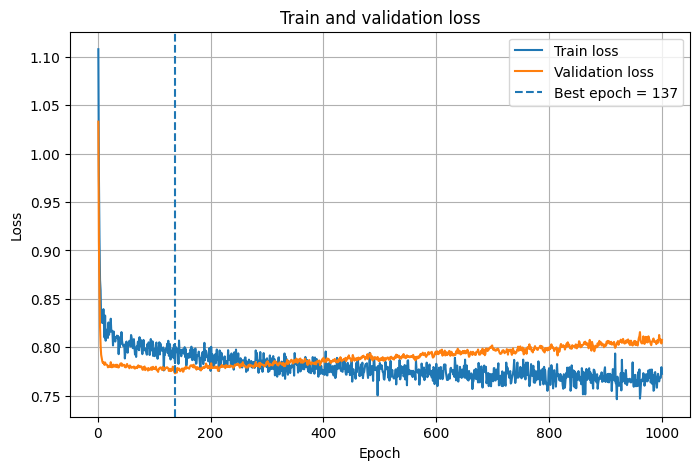

0.5846774193548387

In [6]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [7]:
best_num_epochs = 137

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5847 | Precision: 0.6111 | Recall: 0.5151 | Specificity: 0.7641 | F1: 0.4657

Run 2/10
Accuracy: 0.5726 | Precision: 0.3917 | Recall: 0.4966 | Specificity: 0.7529 | F1: 0.4283

Run 3/10
Accuracy: 0.5726 | Precision: 0.3850 | Recall: 0.4966 | Specificity: 0.7549 | F1: 0.4261

Run 4/10
Accuracy: 0.5685 | Precision: 0.3817 | Recall: 0.4916 | Specificity: 0.7524 | F1: 0.4216

Run 5/10
Accuracy: 0.5726 | Precision: 0.3917 | Recall: 0.4966 | Specificity: 0.7529 | F1: 0.4283

Run 6/10
Accuracy: 0.5806 | Precision: 0.5748 | Recall: 0.5098 | Specificity: 0.7616 | F1: 0.4677

Run 7/10
Accuracy: 0.5685 | Precision: 0.3839 | Recall: 0.4916 | Specificity: 0.7517 | F1: 0.4223

Run 8/10
Accuracy: 0.5726 | Precision: 0.3917 | Recall: 0.4966 | Specificity: 0.7529 | F1: 0.4283

Run 9/10
Accuracy: 0.5685 | Precision: 0.3853 | Recall: 0.4937 | Specificity: 0.7517 | F1: 0.4246

Run 10/10
Accuracy: 0.5645 | Precision: 0.3784 | Recall: 0.4865 | Specificity: 0.7499 | F1: 0.4171

Summary o

In [8]:
save_result(
    experiment_name="Experiment_1-2_ELO_ranks",
    summary=summary
)


Saved result for Experiment_1-2_ELO_ranks
File: ../results/experiment_summary_final.csv


In [11]:
save_result_v1(
    experiment_name="Experiment_1-2_ELO_ranks",
    summary=summary
)


Saved result for Experiment_1-2_ELO_ranks
File: ../results/experiment_summary_v1.csv
